# South Africa Crime Statistics Analysis (2013-2023)

## Overview
This project analyses official SAPS (South African Police Service) crime data 
spanning 10 years across all 9 provinces and 39 crime categories.

## Key Findings
- **Gauteng** has the highest total crime volume, followed by Western Cape and KwaZulu-Natal
- **KwaZulu-Natal** has seen the sharpest rise in murder, overtaking Gauteng since 2021
- **Western Cape** shows disproportionately high drug-related crime relative to its population
- **COVID-19 lockdown (2020-2021)** caused a visible dip in movement-dependent crimes 
  (burglary, drug-related crime) while interpersonal crimes (murder, rape) stayed relatively stable

## Data Source
Official SAPS Annual Crime Statistics, 2023-2024 release (saps.gov.za)

## Tools Used
Python, pandas, matplotlib, seaborn, JupyterLab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Read directly from Excel, RAW Data sheet
df = pd.read_excel("2023-2024 _Annual_Stats.xlsx", 
                   sheet_name="RAW Data",
                   header=2)

print(df.shape)
df.head()

(49084, 47)


,Crime_Category National contribution\nplacement,Crime_Category Provincial contribution\nplacement,Comp level,Station Crime_Category,Station,District,Province,Crime_Category,Code,2013-2014,...,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46
0,Murder Station 524,Eastern Cape Murder Station 98,Station,Afsondering Murder,Afsondering,Alfred Nzo District,Eastern Cape,Murder,1,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Attempted murder Station 687,Eastern Cape Attempted murder Station 90,Station,Afsondering Attempted murder,Afsondering,Alfred Nzo District,Eastern Cape,Attempted murder,2,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Robbery with aggravating circumstances Station...,Eastern Cape Robbery with aggravating circumst...,Station,Afsondering Robbery with aggravating circumsta...,Afsondering,Alfred Nzo District,Eastern Cape,Robbery with aggravating circumstances,4,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Common robbery Station 1075,Eastern Cape Common robbery Station 170,Station,Afsondering Common robbery,Afsondering,Alfred Nzo District,Eastern Cape,Common robbery,6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Rape Station 672,Eastern Cape Rape Station 110,Station,Afsondering Rape,Afsondering,Alfred Nzo District,Eastern Cape,Rape,9,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import subprocess
subprocess.run(["pip", "install", "openpyxl", "--break-system-packages"])

CompletedProcess(args=['pip', 'install', 'openpyxl', '--break-system-packages'], returncode=0)

In [3]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Read directly from Excel, RAW Data sheet
df = pd.read_excel("2023-2024 _Annual_Stats.xlsx", 
                   sheet_name="RAW Data",
                   header=2)

print(df.shape)
df.head()

(49084, 47)


,Crime_Category National contribution\nplacement,Crime_Category Provincial contribution\nplacement,Comp level,Station Crime_Category,Station,District,Province,Crime_Category,Code,2013-2014,...,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46
0,Murder Station 524,Eastern Cape Murder Station 98,Station,Afsondering Murder,Afsondering,Alfred Nzo District,Eastern Cape,Murder,1,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Attempted murder Station 687,Eastern Cape Attempted murder Station 90,Station,Afsondering Attempted murder,Afsondering,Alfred Nzo District,Eastern Cape,Attempted murder,2,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Robbery with aggravating circumstances Station...,Eastern Cape Robbery with aggravating circumst...,Station,Afsondering Robbery with aggravating circumsta...,Afsondering,Alfred Nzo District,Eastern Cape,Robbery with aggravating circumstances,4,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Common robbery Station 1075,Eastern Cape Common robbery Station 170,Station,Afsondering Common robbery,Afsondering,Alfred Nzo District,Eastern Cape,Common robbery,6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Rape Station 672,Eastern Cape Rape Station 110,Station,Afsondering Rape,Afsondering,Alfred Nzo District,Eastern Cape,Rape,9,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Keep only the columns we need
df_clean = df[["Station", "District", "Province", "Crime_Category", "2013-2014"]].copy()

# Check all the columns available
print(df.columns.tolist())


['Crime_Category National contribution\nplacement', 'Crime_Category Provincial contribution\nplacement', 'Comp level', 'Station Crime_Category', 'Station', 'District', 'Province', 'Crime_Category', 'Code', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', 'National contribution\nplacement', 'National count diff\nplacement', 'Provincial contribution\nplacement', 'Provincial count diff\nplacement', 'Count direction', 'Count offence group', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46']


In [6]:
# Keep only the useful columns
df_clean = df[["Station", "District", "Province", "Crime_Category", 
               "2013-2014", "2014-2015", "2015-2016", "2016-2017",
               "2017-2018", "2018-2019", "2019-2020", "2020-2021",
               "2021-2022", "2022-2023"]].copy()

# Check it
print(df_clean.shape)
print("\nMissing values:\n", df_clean.isnull().sum())
df_clean.head()


(49084, 14)

Missing values:
 Station              4
District          1231
Province          1231
Crime_Category    1231
2013-2014         1231
2014-2015         1231
2015-2016         1231
2016-2017         1231
2017-2018         1231
2018-2019         1231
2019-2020         1231
2020-2021         1231
2021-2022         1231
2022-2023         1231
dtype: int64


,Station,District,Province,Crime_Category,2013-2014,2014-2015,2015-2016,2016-2017,2017-2018,2018-2019,2019-2020,2020-2021,2021-2022,2022-2023
0,Afsondering,Alfred Nzo District,Eastern Cape,Murder,14.0,15.0,9.0,18.0,4.0,7.0,6.0,12.0,20.0,11.0
1,Afsondering,Alfred Nzo District,Eastern Cape,Attempted murder,4.0,8.0,5.0,3.0,2.0,1.0,5.0,5.0,5.0,6.0
2,Afsondering,Alfred Nzo District,Eastern Cape,Robbery with aggravating circumstances,8.0,14.0,13.0,12.0,21.0,14.0,9.0,9.0,6.0,8.0
3,Afsondering,Alfred Nzo District,Eastern Cape,Common robbery,1.0,2.0,0.0,0.0,4.0,2.0,1.0,1.0,0.0,0.0
4,Afsondering,Alfred Nzo District,Eastern Cape,Rape,13.0,7.0,22.0,13.0,20.0,8.0,13.0,17.0,15.0,17.0


In [7]:
# Drop rows where critical data is missing
df_clean = df_clean.dropna(subset=["Province", "Crime_Category"])

# Confirm clean
print("Clean dataset shape:", df_clean.shape)
print("\nProvinces:", df_clean["Province"].unique())
print("\nCrime types:", df_clean["Crime_Category"].unique())

Clean dataset shape: (47853, 14)

Provinces: <StringArray>
[            'Eastern Cape',               'Free State',
                  'Gauteng',            'KwaZulu-Natal',
                  'Limpopo',               'Mpumalanga',
               'North West',            'Northern Cape',
             'Western Cape', 'Republic of South Africa',
                      'RSA',                 'National']
Length: 12, dtype: str

Crime types: <StringArray>
[                                                 'Murder',
                                        'Attempted murder',
                  'Robbery with aggravating circumstances',
                                          'Common robbery',
                                                    'Rape',
                                          'Sexual assault',
                                              'Kidnapping',
 'Assault with the intent to inflict grievous bodily harm',
                                          'Common assault',
        

In [8]:
# Keep only the 9 actual provinces
provinces = ['Eastern Cape', 'Free State', 'Gauteng', 'KwaZulu-Natal', 
             'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']

df_clean = df_clean[df_clean["Province"].isin(provinces)]

print("Final shape:", df_clean.shape)
print("Provinces:", df_clean["Province"].unique())


Final shape: (45318, 14)
Provinces: <StringArray>
[ 'Eastern Cape',    'Free State',       'Gauteng', 'KwaZulu-Natal',
       'Limpopo',    'Mpumalanga',    'North West', 'Northern Cape',
  'Western Cape']
Length: 9, dtype: str


/tmp/ipykernel_7168/3158065750.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_totals.values, y=province_totals.index, palette="Reds_r")


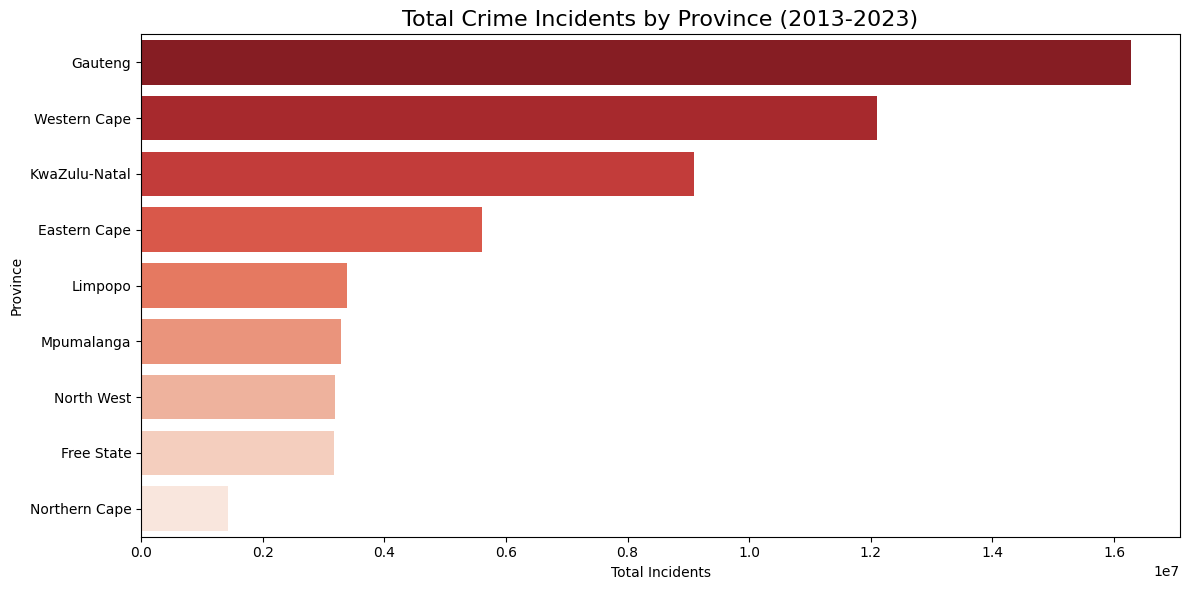

Province
Gauteng          16270402.0
Western Cape     12107538.0
KwaZulu-Natal     9085938.0
Eastern Cape      5604463.0
Limpopo           3388681.0
Mpumalanga        3290661.0
North West        3189407.0
Free State        3170465.0
Northern Cape     1422048.0
dtype: float64


In [9]:
# Total incidents per province across all years
province_totals = df_clean.groupby("Province")[["2013-2014", "2014-2015", 
                                                 "2015-2016", "2016-2017",
                                                 "2017-2018", "2018-2019",
                                                 "2019-2020", "2020-2021",
                                                 "2021-2022", "2022-2023"]].sum().sum(axis=1).sort_values(ascending=False)

# Plot it
plt.figure(figsize=(12, 6))
sns.barplot(x=province_totals.values, y=province_totals.index, palette="Reds_r")
plt.title("Total Crime Incidents by Province (2013-2023)", fontsize=16)
plt.xlabel("Total Incidents")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

print(province_totals)

In [10]:
# Export cleaned data for Tableau
df_clean.to_csv("crime_data_for_tableau.csv", index=False)
print("Exported successfully")

Exported successfully


/tmp/ipykernel_7168/2364249903.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_totals.values, y=crime_totals.index, palette="Reds_r")


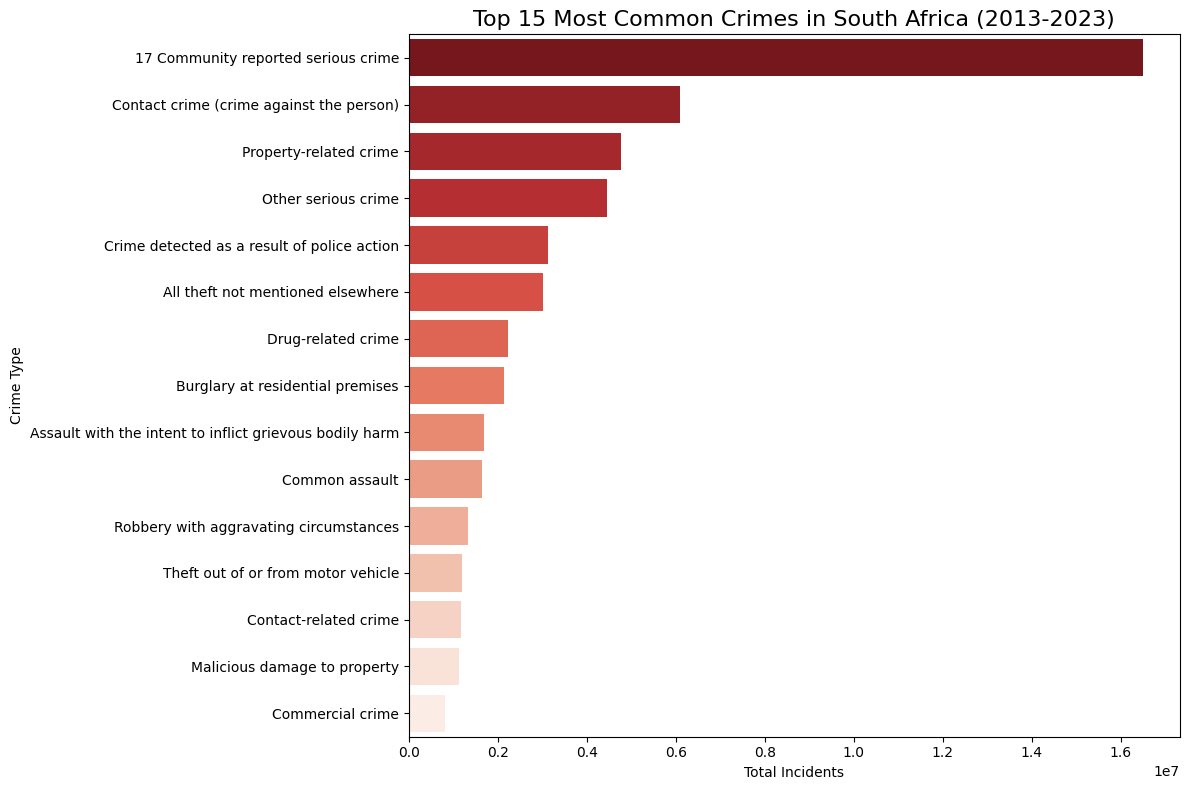

In [11]:
# Total incidents per crime type across all years
years = ["2013-2014", "2014-2015", "2015-2016", "2016-2017",
         "2017-2018", "2018-2019", "2019-2020", "2020-2021",
         "2021-2022", "2022-2023"]

crime_totals = df_clean.groupby("Crime_Category")[years].sum().sum(axis=1).sort_values(ascending=False).head(15)

# Plot it
plt.figure(figsize=(12, 8))
sns.barplot(x=crime_totals.values, y=crime_totals.index, palette="Reds_r")
plt.title("Top 15 Most Common Crimes in South Africa (2013-2023)", fontsize=16)
plt.xlabel("Total Incidents")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()

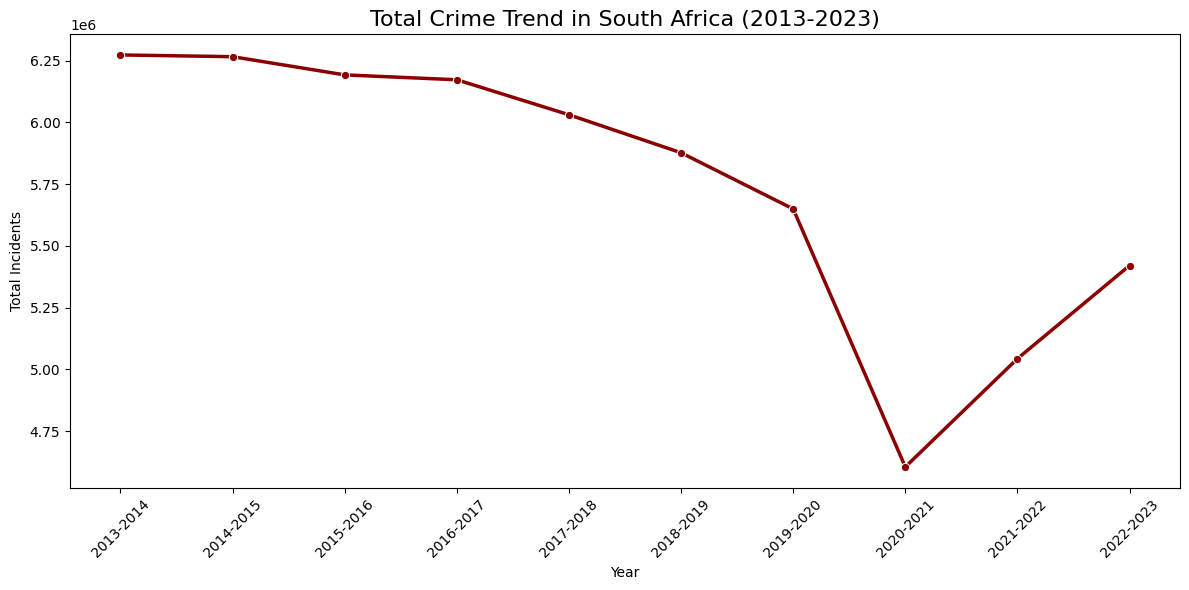

2013-2014    6272996.0
2014-2015    6265851.0
2015-2016    6192205.0
2016-2017    6172451.0
2017-2018    6030811.0
2018-2019    5876910.0
2019-2020    5649477.0
2020-2021    4605088.0
2021-2022    5043315.0
2022-2023    5420499.0
dtype: float64


In [12]:
# How has total crime changed year by year?
yearly_totals = df_clean[years].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_totals.index, y=yearly_totals.values, marker="o", color="darkred", linewidth=2.5)
plt.title("Total Crime Trend in South Africa (2013-2023)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(yearly_totals)


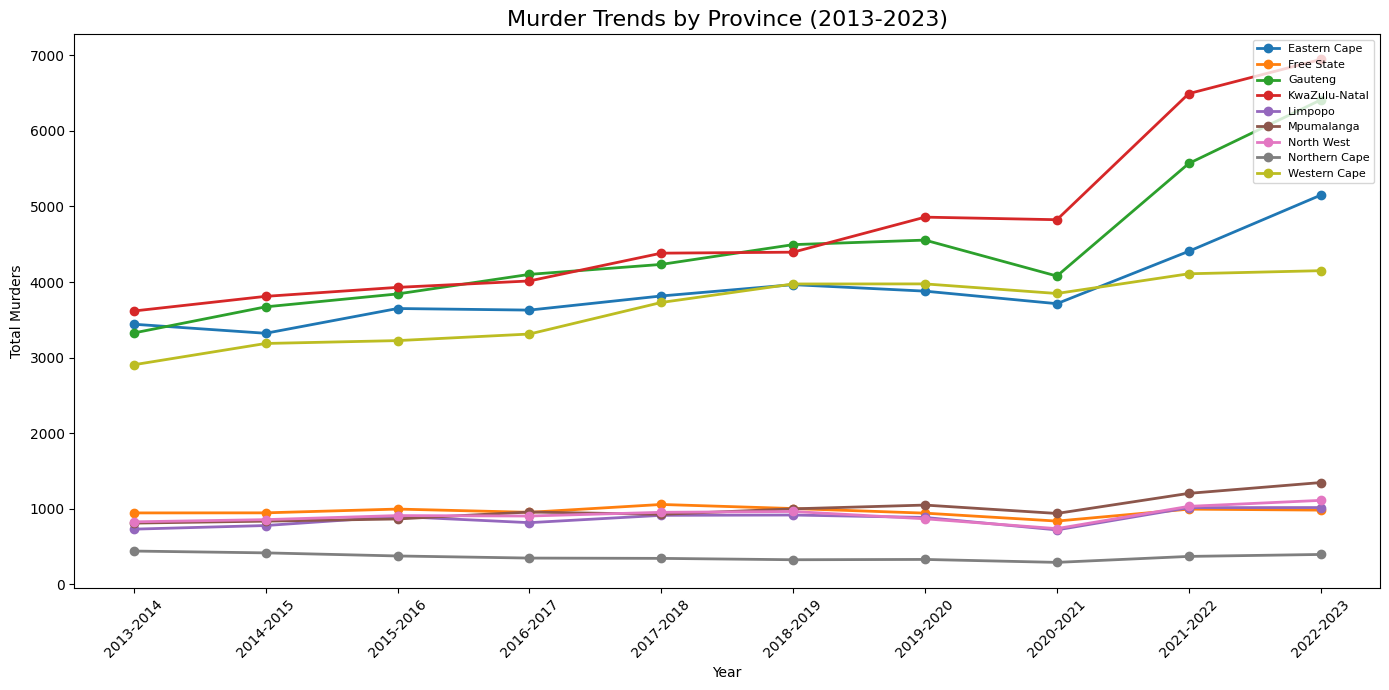

In [13]:
# Murder trend over time by province
murder_df = df_clean[df_clean["Crime_Category"] == "Murder"]
murder_province = murder_df.groupby("Province")[years].sum()

plt.figure(figsize=(14, 7))
for province in murder_province.index:
    plt.plot(years, murder_province.loc[province], marker="o", label=province, linewidth=2)

plt.title("Murder Trends by Province (2013-2023)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Murders")
plt.xticks(rotation=45)
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

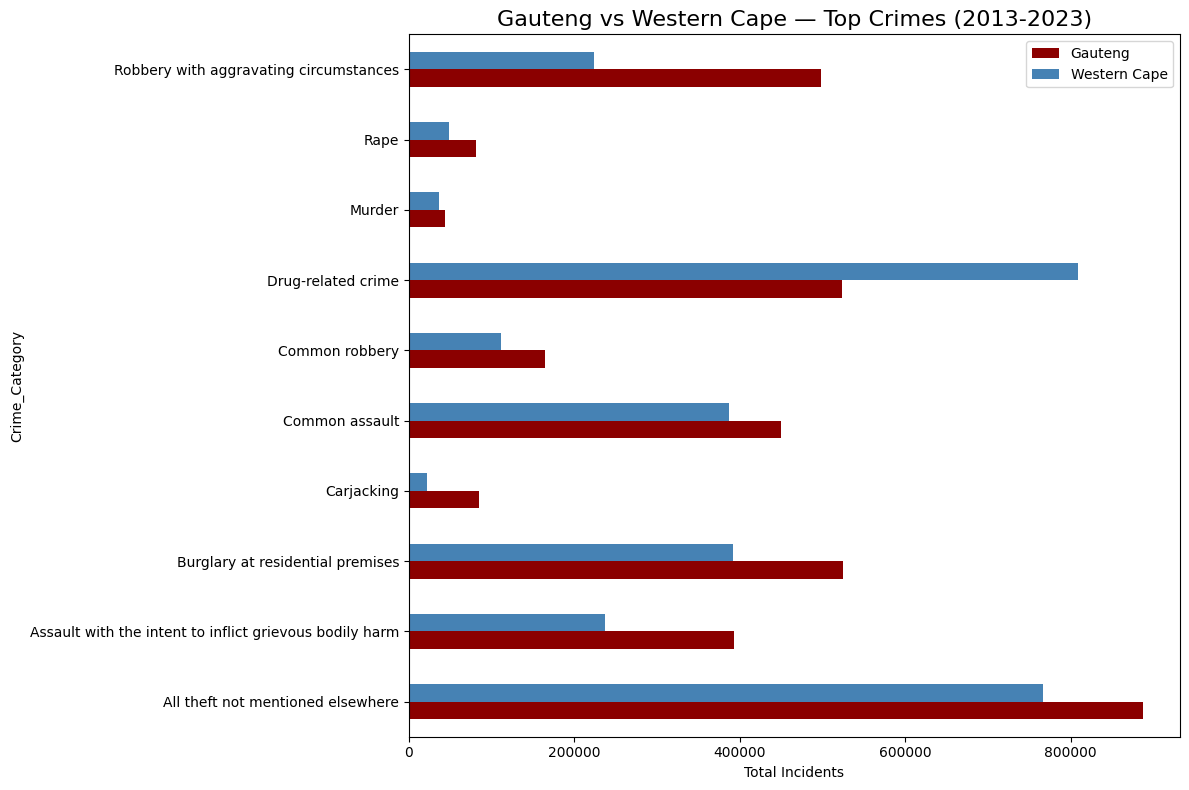

In [14]:
# Compare top crimes Gauteng vs Western Cape
top_crimes = ['Murder', 'Rape', 'Robbery with aggravating circumstances',
              'Burglary at residential premises', 'Common assault',
              'Drug-related crime', 'Carjacking', 'Common robbery',
              'Assault with the intent to inflict grievous bodily harm',
              'All theft not mentioned elsewhere']

gp = df_clean[(df_clean["Province"]=="Gauteng") & 
              (df_clean["Crime_Category"].isin(top_crimes))].groupby("Crime_Category")[years].sum().sum(axis=1)

wc = df_clean[(df_clean["Province"]=="Western Cape") & 
              (df_clean["Crime_Category"].isin(top_crimes))].groupby("Crime_Category")[years].sum().sum(axis=1)

comparison = pd.DataFrame({"Gauteng": gp, "Western Cape": wc})

comparison.plot(kind="barh", figsize=(12, 8), color=["darkred", "steelblue"])
plt.title("Gauteng vs Western Cape — Top Crimes (2013-2023)", fontsize=16)
plt.xlabel("Total Incidents")
plt.tight_layout()
plt.show()

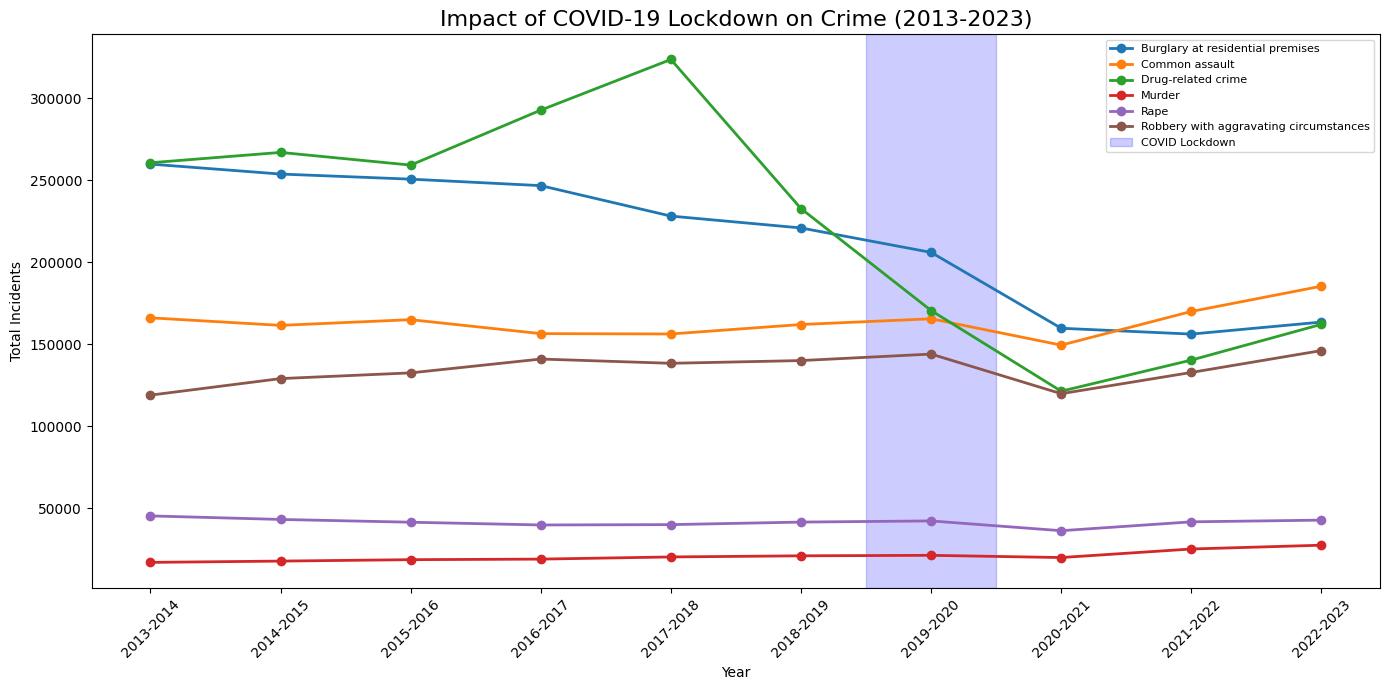

In [15]:
# COVID impact - show 2019-2020 vs 2020-2021 drop and recovery
covid_crimes = ['Murder', 'Rape', 'Common assault', 
                'Burglary at residential premises',
                'Drug-related crime', 'Robbery with aggravating circumstances']

covid_df = df_clean[df_clean["Crime_Category"].isin(covid_crimes)].groupby("Crime_Category")[years].sum()

plt.figure(figsize=(14, 7))
for crime in covid_df.index:
    plt.plot(years, covid_df.loc[crime], marker="o", label=crime, linewidth=2)

plt.axvspan(5.5, 6.5, alpha=0.2, color='blue', label="COVID Lockdown")
plt.title("Impact of COVID-19 Lockdown on Crime (2013-2023)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Incidents")
plt.xticks(rotation=45)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
import openpyxl
wb = openpyxl.load_workbook("2023-2024 _Annual_Stats.xlsx", read_only=True)
print(wb.sheetnames)

['Lookup lists', 'RAW Data', 'Stats per comp', 'Stats RSA & PHO summary', 'TOP30 stations', 'TOP30 stations CDPA', 'Graph month trend', 'Graph month trend CDPA']


In [17]:
# Reshape data for Tableau trend chart - one row per year instead of one column per year
df_trend = df_clean.melt(
    id_vars=["Station", "District", "Province", "Crime_Category"],
    value_vars=years,
    var_name="Year",
    value_name="Incidents"
)

df_trend.to_csv("crime_data_long_format.csv", index=False)
print("Exported successfully, shape:", df_trend.shape)

Exported successfully, shape: (453180, 6)
